<a href="https://colab.research.google.com/github/Anjali-7777/GenAI_Practicals_Anjali/blob/main/Practical_2/GenAI_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
!pip install -q gensim plotly pandas matplotlib scikit-learn


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [13]:
from gensim.models import Word2Vec

sentences = [
    ['the', 'king', 'rules', 'the', 'kingdom'],
    ['the', 'prince', 'rules', 'the', 'kingdom'],
    ['the', 'queen', 'rules', 'the', 'kingdom'],
    ['the', 'doctor', 'works', 'in', 'the', 'hospital'],
    ['the', 'nurse', 'works', 'in', 'the', 'hospital'],
    ['the', 'teacher', 'works', 'in', 'the', 'school'],
    ['the', 'man', 'works', 'in', 'the', 'hospital'],
    ['the', 'woman', 'works', 'in', 'the', 'hospital'],
    ['an', 'apple', 'is', 'a', 'tasty', 'fruit'],
    ['a', 'banana', 'is', 'a', 'tasty', 'fruit'],
    ['a', 'mango', 'is', 'a', 'tasty', 'fruit'],
]

print("----- Training Models -----")

# CBOW model
model_cbow = Word2Vec(
    sentences,
    vector_size=10,
    window=2,
    min_count=1,
    sg=0,
    epochs=100
)

print("CBOW model trained successfully")

# Skip-gram model
model_skipgram = Word2Vec(
    sentences,
    vector_size=10,
    window=2,
    min_count=1,
    sg=1,
    epochs=100
)

print("Skip-gram model trained successfully")


def test_similarities(model, model_name):
    print(f"\n---- Semantic Similarities using {model_name} ----")

    sim_royal = model.wv.similarity('queen', 'king')
    print(f"Similarity ('queen', 'king'): {sim_royal:.4f}")

    sim_fruit = model.wv.similarity('apple', 'mango')
    print(f"Similarity ('apple', 'mango'): {sim_fruit:.4f}")

    sim_unrelated = model.wv.similarity('queen', 'apple')
    print(f"Similarity ('queen', 'apple'): {sim_unrelated:.4f}")


test_similarities(model_cbow, "CBOW")
test_similarities(model_skipgram, "Skip-gram")

----- Training Models -----
CBOW model trained successfully
Skip-gram model trained successfully

---- Semantic Similarities using CBOW ----
Similarity ('queen', 'king'): 0.3366
Similarity ('apple', 'mango'): -0.0553
Similarity ('queen', 'apple'): 0.3302

---- Semantic Similarities using Skip-gram ----
Similarity ('queen', 'king'): 0.3410
Similarity ('apple', 'mango'): -0.0582
Similarity ('queen', 'apple'): 0.3267


In [14]:
print("----- Similar Words using CBOW -----")

print("\nWords similar to 'king':")
print(model_cbow.wv.most_similar('king', topn=5))

print("\nWords similar to 'apple':")
print(model_cbow.wv.most_similar('apple', topn=5))

----- Similar Words using CBOW -----

Words similar to 'king':
[('tasty', 0.579895555973053), ('fruit', 0.5618032813072205), ('prince', 0.5507448315620422), ('doctor', 0.46484971046447754), ('apple', 0.3509790003299713)]

Words similar to 'apple':
[('rules', 0.49213486909866333), ('an', 0.44470739364624023), ('tasty', 0.4179709851741791), ('doctor', 0.3890077769756317), ('king', 0.3509790301322937)]


In [15]:
import gensim
from gensim.models import KeyedVectors
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [16]:
print("Gensim version: ",gensim.__version__)

Gensim version:  4.4.0


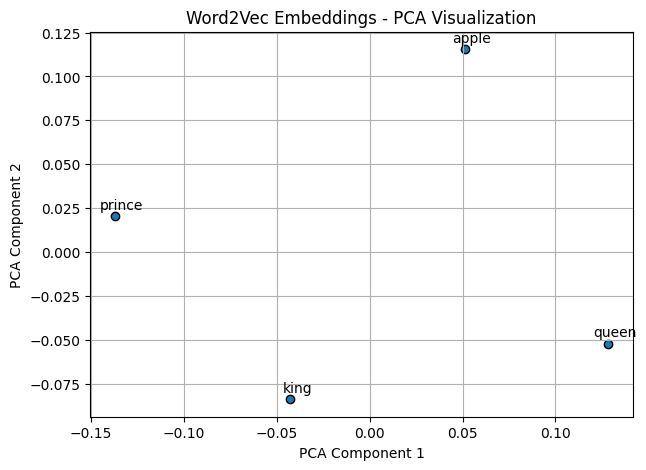

In [17]:
words_to_visualize = [
    'king', 'queen', 'prince', 'apple'
]

filtered_words = [
    word for word in words_to_visualize
    if word in model_cbow.wv.key_to_index
]

vectors = [
    model_cbow.wv[word]
    for word in filtered_words
]

pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

plt.figure(figsize=(7, 5))
plt.scatter(
    vectors_2d[:, 0],
    vectors_2d[:, 1],
    edgecolors='k'
)

for i, word in enumerate(filtered_words):
    plt.annotate(
        word,
        (vectors_2d[i, 0], vectors_2d[i, 1]),
        textcoords="offset points",
        xytext=(5, 5),
        ha='center'
    )

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Word2Vec Embeddings - PCA Visualization')
plt.grid(True)
plt.show()



Vector Arithmetic: Analogies

In [18]:
# Vector Arithmetic: Analogies

similar_words = model_cbow.wv.most_similar(
    positive=['king', 'woman'],
    negative=['man'],
    topn=5
)

print("Analogy: king - man + woman")

for word, score in similar_words:
    print(f"{word}: {score:.4f}")

Analogy: king - man + woman
tasty: 0.5026
fruit: 0.4556
school: 0.4408
is: 0.4091
doctor: 0.3381


In [19]:
!pip install -q plotly


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [20]:
import plotly.express as px
import pandas as pd

# Create DataFrame for Plotly
data_for_plotly = pd.DataFrame({
    'word': filtered_words,
    'x': vectors_2d[:, 0],
    'y': vectors_2d[:, 1]
})

# Get words
words = data_for_plotly['word'].tolist()

# Create similarity matrix
similarity_matrix = pd.DataFrame(
    index=words,
    columns=words,
    dtype=float
)

for i in range(len(words)):
    for j in range(len(words)):
        similarity_matrix.iloc[i, j] = model_cbow.wv.similarity(
            words[i],
            words[j]
        )
# Plot similarity matrix
fig = px.imshow(
    similarity_matrix,
    text_auto=True,
    aspect="auto",
    color_continuous_scale="RdBu_r",
    title="Word Similarity Matrix"
)

fig.update_layout(
    xaxis_title="Words",
    yaxis_title="Words"
)

fig.show()